# Exploratory Data Analysis: Iris Dataset

This notebook performs EDA on the `Iris.csv` file present in the repository. Cells are not executed — they only contain the analysis steps, visualizations, and conclusions.

In [3]:
%pip install pandas numpy matplotlib seaborn
# 1) imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(style="whitegrid")

  Using cached matplotlib-3.10.9-cp313-cp313-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-macosx_10_13_universal2.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 3.7 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 3.8 MB/s  0:00:01 eta 0:00:01
Using cached matplotlib-3.10.9-cp313-cp313-macosx_11_0_arm64.whl (8.2 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached 

In [4]:
# 2) load the data
df = pd.read_csv('Iris.csv')
df.shape

(150, 6)

In [5]:
# 3) quick look
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
# 4) info / dtypes / missing values
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [7]:
# 5) descriptive statistics for numeric columns
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [8]:
# 6) value counts for species
if 'Species' in df.columns:
    df['Species'].value_counts()
else:
    print('Species column not found; check column names: ', df.columns)

## Visualizations: Distributions and relationships
Below are plotting steps to explore feature distributions and relationships between features and species.

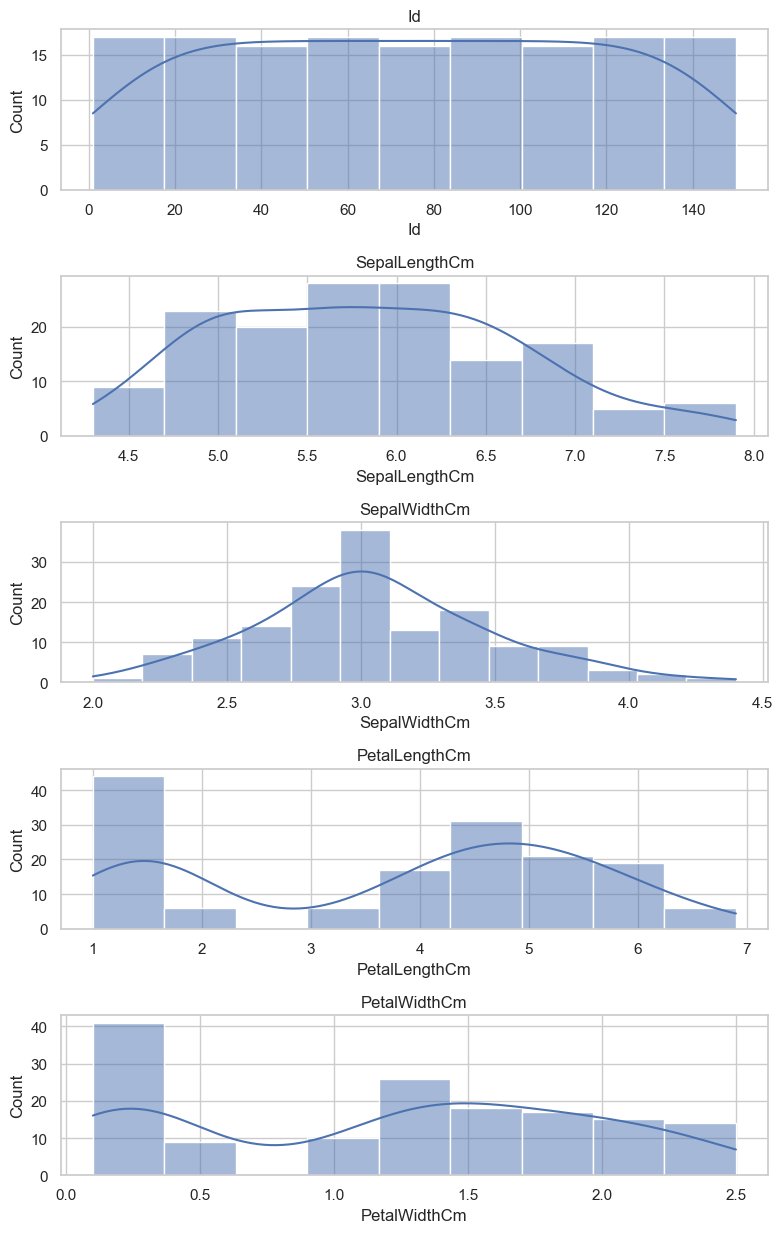

In [9]:
# 7) histograms / KDE for numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(8, len(numeric_cols)*2.5))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()

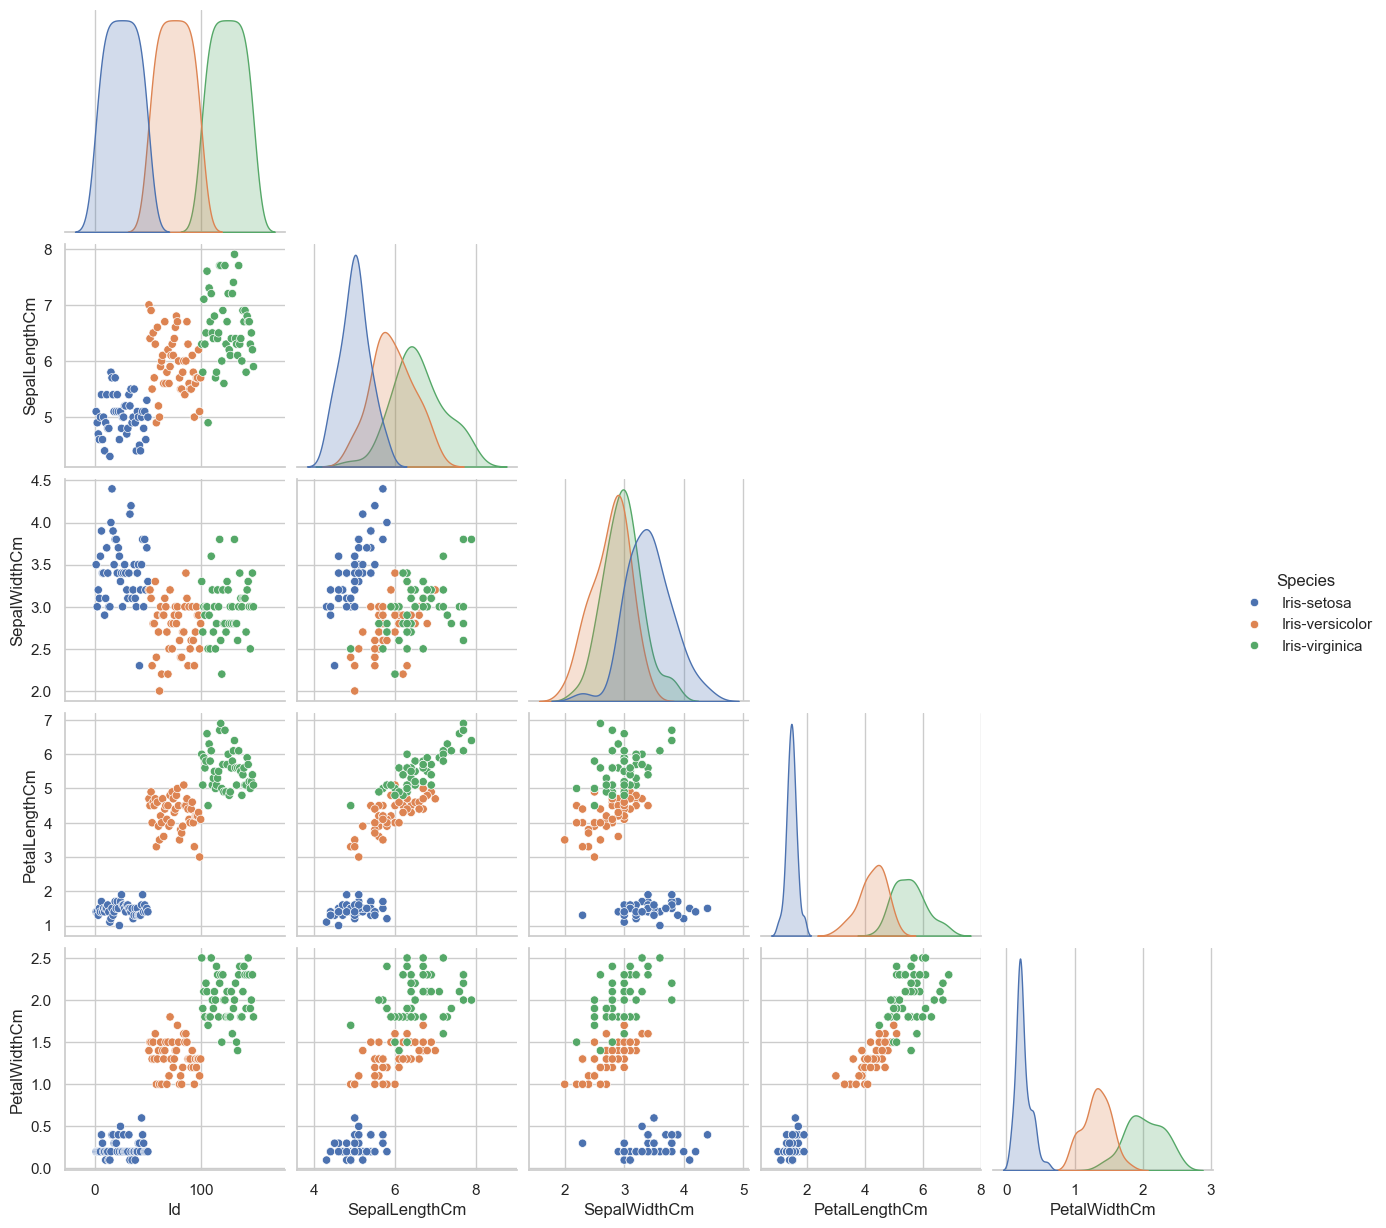

In [10]:
# 8) pairplot colored by species
if 'Species' in df.columns:
    sns.pairplot(df, hue='Species', corner=True)
else:
    print('Species column missing; skipping pairplot')

Text(0.5, 1.0, 'Correlation matrix (numeric features)')

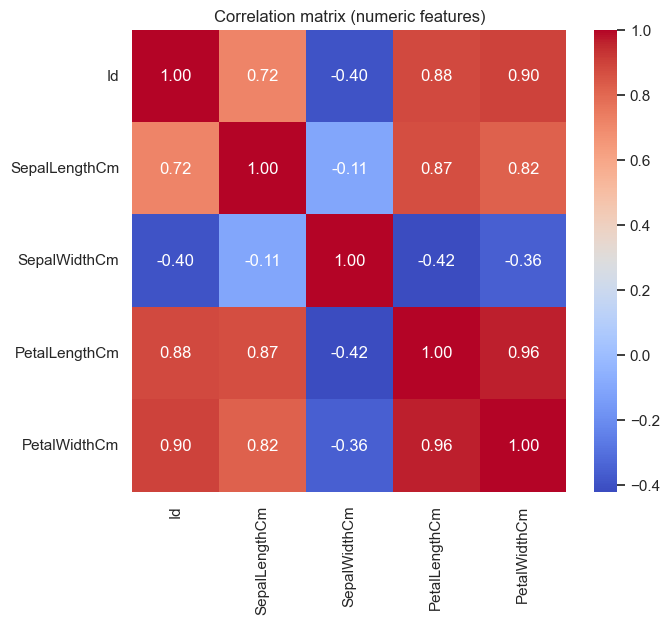

In [11]:
# 9) correlation matrix and heatmap (numeric features)
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix (numeric features)')

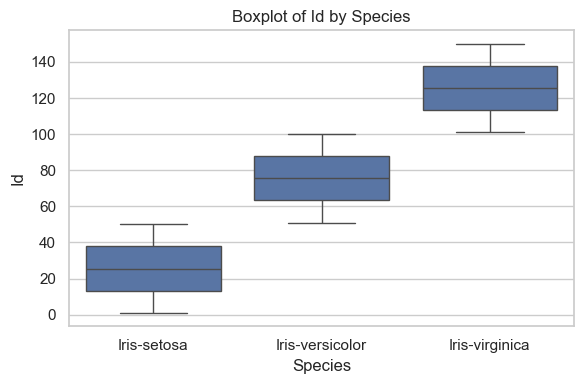

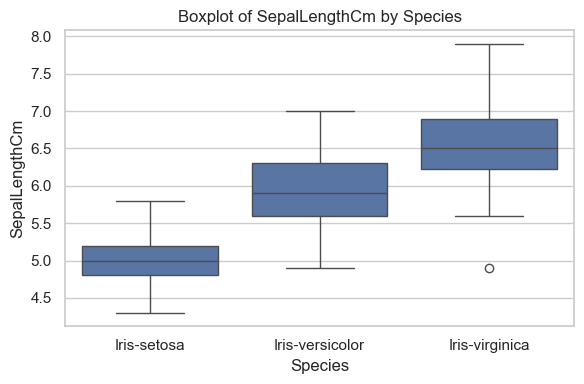

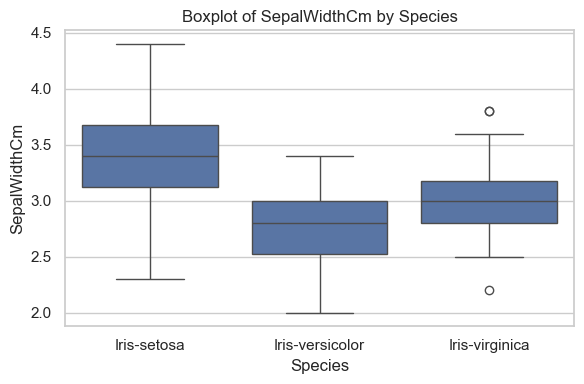

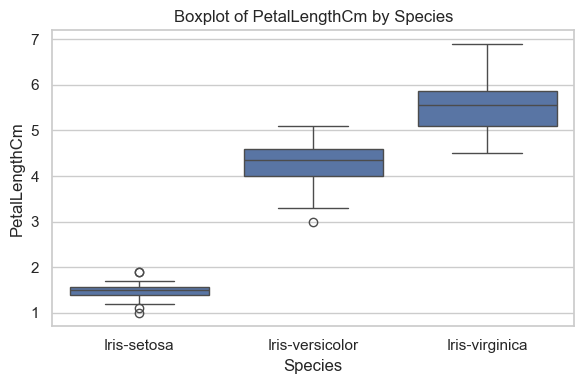

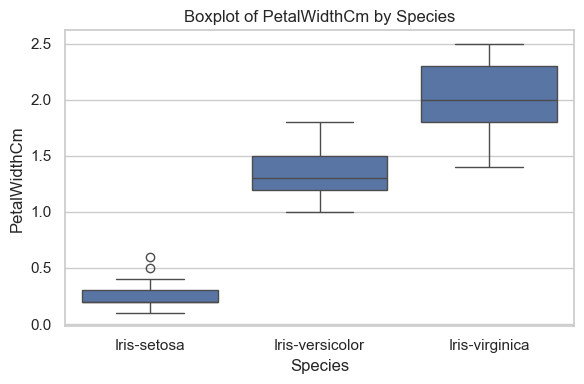

In [12]:
# 10) boxplots of each numeric feature grouped by species
if 'Species' in df.columns:
    for col in numeric_cols:
        plt.figure(figsize=(6,4))
        sns.boxplot(x='Species', y=col, data=df)
        plt.title(f'Boxplot of {col} by Species')
        plt.tight_layout()
else:
    print('Species column missing; skipping boxplots')

## Conclusions
- Provide a concise summary of findings here after running the notebook. Example starter points:
  - Check for missing values: the dataset is expected to be complete (no missing values).
  - Species balance: the dataset typically contains balanced classes for each species.
  - Correlations: sepal/petal length/width correlations — petal length and petal width are often strongly correlated.
  - Separability: Setosa is usually separable from Versicolor and Virginica using petal measurements; Versicolor and Virginica overlap more.

After running the above cells, refine these conclusions with exact numbers and plots.